# 02 - Mainnet CPMM

Raydium CPMM analysis for snapshot-derived CPMM scenarios and the historical CPMM decoding pipeline.

Inputs:
- `results/real_pool_comparison.csv`
- `results/historical_cpmm_swaps_status.csv`
- `results/historical_cpmm_pipeline_summary.csv`
- `results/historical_cpmm_decoded.csv`
- `results/historical_cpmm_candidates.csv`


## Data readiness


In [1]:
from pathlib import Path
import sys

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "helpers").exists():
        sys.path.insert(0, str(candidate))
        break
    if (candidate / "notebooks" / "helpers").exists():
        sys.path.insert(0, str(candidate / "notebooks"))
        break

import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from helpers import (
    blocker_table,
    data_readiness,
    find_repo_root,
    historical_candidate_summary,
    historical_pipeline_funnel,
    historical_rejection_pareto,
    historical_slippage_summary,
    historical_takeaway_lines,
    historical_top_candidates,
    hypothesis_scorecard,
    load_inputs,
    plot_profit_distribution,
    plot_rejection_pareto,
    plot_size_vs_profit,
    plot_slippage_feasibility,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

ROOT = find_repo_root()
inputs = load_inputs(ROOT)

comparison = inputs["frames"]["real_pool_comparison"]
historical = inputs["frames"]["historical_cpmm_candidates"]
historical_frames = {
    name: inputs["frames"][name]
    for name in [
        "historical_cpmm_swaps_status",
        "historical_cpmm_pipeline_summary",
        "historical_cpmm_decoded",
        "historical_cpmm_candidates",
    ]
}
funnel = historical_pipeline_funnel(historical_frames)
rejections = historical_rejection_pareto(historical_frames)

readiness_names = ["real_pool_comparison", *historical_frames.keys()]
display(data_readiness(ROOT, inputs, readiness_names))
if comparison.attrs.get("legacy_schema", False):
    display(Markdown("> CPMM comparison CSV is old-schema. Regenerate before final thesis numbers."))


/Users/piotrgasiorek/Studia/magisterka/notebooks/helpers/loading.py:27: DtypeWarning: Columns (0: error) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


,dataset,file,rows,columns,ready_for_final_numbers,note
0,real_pool_comparison,results/real_pool_comparison.csv,32,36,True,ok
1,historical_cpmm_swaps_status,results/cpmm_24h_sunday/historical_cpmm_swaps_...,101746,16,True,ok
2,historical_cpmm_pipeline_summary,results/cpmm_24h_sunday/historical_cpmm_pipeli...,6,7,True,ok
3,historical_cpmm_decoded,results/cpmm_24h_sunday/historical_cpmm_decode...,6719,18,True,ok
4,historical_cpmm_candidates,results/cpmm_24h_sunday/historical_cpmm_candid...,6719,51,False,legacy schema: regenerate CSV


## Snapshot CPMM scorecard


In [2]:
if comparison.empty:
    display(Markdown("Generate `results/real_pool_comparison.csv` first."))
else:
    display(hypothesis_scorecard(comparison))
    display(blocker_table(comparison))


,question,metric,value
0,Czy atak zarabia przed slippage filter?,profitable rows,50.0%
1,Czy ofiara nie revertuje?,feasible rows,75.0%
2,Czy atak jest ekonomicznie realizowalny?,profitable and feasible rows,25.0%
3,Typowy wynik attackera,median net profit,"8,272,240"
4,Typowa strata ofiary w udanych przypadkach,median victim loss bps,51


,blocker,rows,share,median_net_profit,median_victim_loss_bps
0,not_profitable,16,0.50,-3.598298e+06,2.5
1,realized,8,0.25,1.904890e+07,51.0
2,victim_would_revert,8,0.25,4.699981e+09,478.0


## Historical pipeline funnel


In [3]:
display(funnel)


,stage,rows
0,collected_signatures,101746
1,decoded_swaps,6719
2,evaluated_rows,6719
3,analysis_candidates,6714
4,excluded_below_threshold,4556
5,rejected_rows,95027


## Rejection Pareto


,reason,rows,share,cumulative_share
0,tx_failed,54245,0.570838,0.570838
1,no_cpmm_swap,39229,0.412820,0.983657
2,multi_swap_ambiguous,801,0.008429,0.992086
3,unsupported_swap_instruction,748,0.007871,0.999958
4,decode_failed,4,0.000042,1.000000


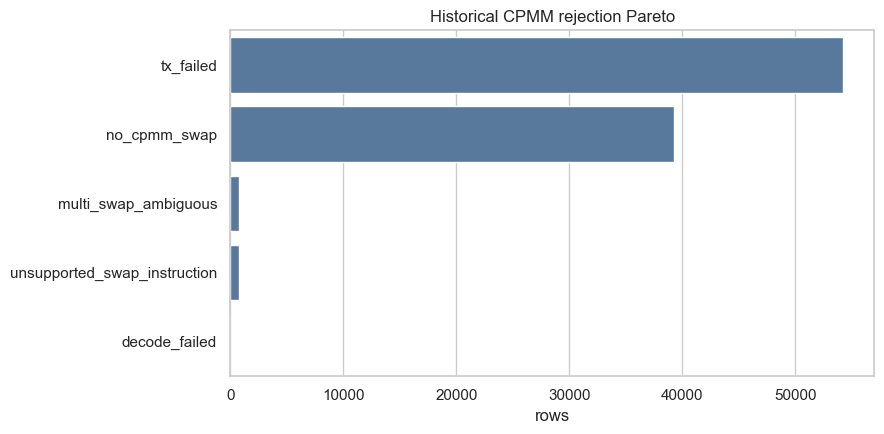

In [4]:
if rejections.empty:
    display(Markdown("No historical CPMM rejection reasons available yet."))
else:
    display(rejections)
    fig = plot_rejection_pareto(rejections)
    if fig is None:
        display(Markdown("Rejection Pareto plot omitted because the data is flat or single-point."))


## Historical candidate summary


In [5]:
display(historical_candidate_summary(historical))


,metric,value
0,evaluated rows,6719
1,excluded below threshold,5
2,analysis candidates,6714
3,profitable rate,1.5%
4,feasible rate,1.5%
5,realized rate,1.5%
6,median net profit,0.0
7,max net profit,226540741219074
8,positive profit rows,98


## Profit distribution


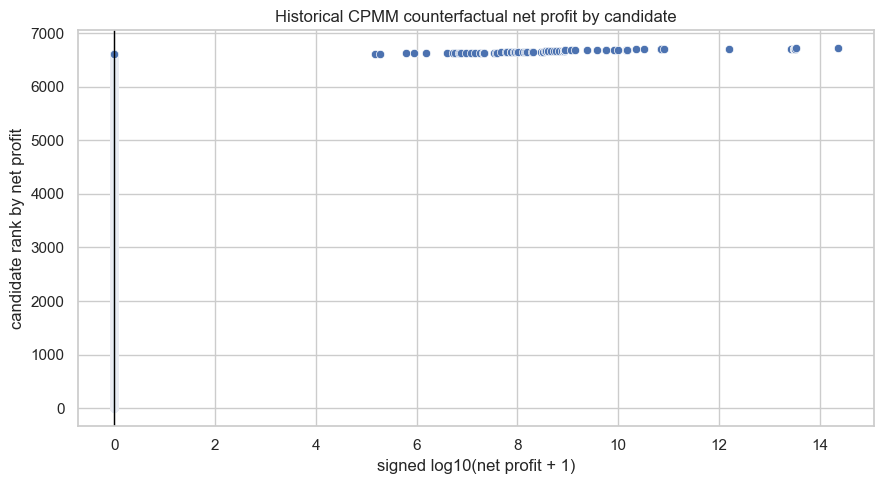

In [6]:
fig = plot_profit_distribution(historical)
if fig is None:
    display(Markdown("Profit distribution plot omitted because candidate profit data is missing, flat, or single-point."))


## Size vs profit


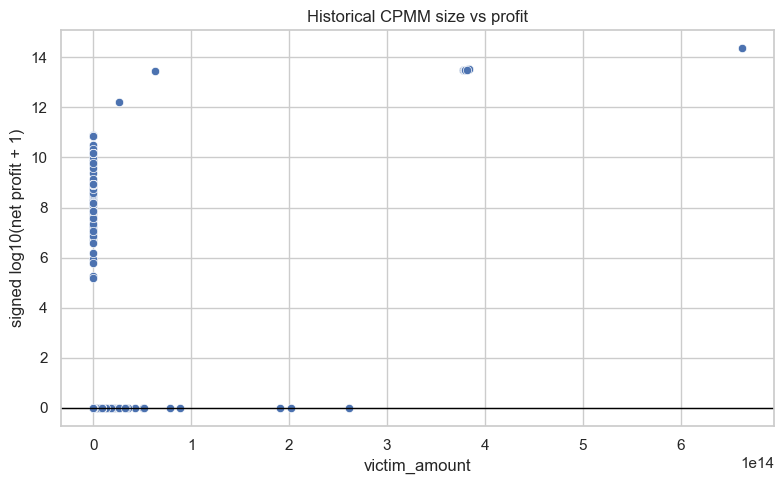

In [7]:
fig = plot_size_vs_profit(historical)
if fig is None:
    display(Markdown("Size-vs-profit plot omitted because candidate size/profit data is missing, flat, or single-point."))


## Slippage feasibility


,metric,value
0,rows with slippage data,6714
1,slippage-feasible rate,99.3%
2,median tolerance margin bps,10000.0
3,min tolerance margin bps,-7285.0


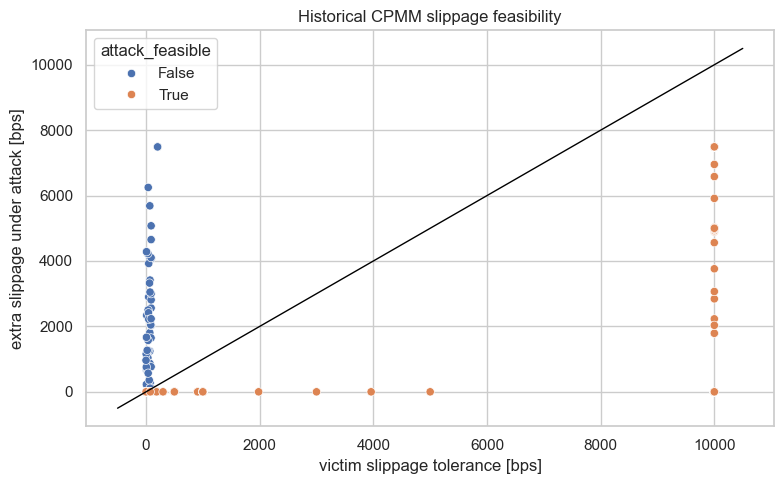

In [8]:
slippage_summary = historical_slippage_summary(historical)
if slippage_summary.empty:
    display(Markdown("No historical CPMM slippage feasibility columns available yet."))
else:
    display(slippage_summary)
fig = plot_slippage_feasibility(historical)
if fig is None:
    display(Markdown("Slippage feasibility plot omitted because the data is missing, flat, or single-point."))


## Top-N candidates


In [9]:
top_candidates = historical_top_candidates(historical, limit=10)
if top_candidates.empty:
    display(Markdown("No ranked historical CPMM candidates yet."))
else:
    display(top_candidates)


,signature,slot,pool_label,victim_amount,amount_in,frontrun_amount,victim_slippage_tolerance_bps,victim_extra_slippage_bps,attacker_net_profit
6483,ioCm4SEn5W9UgypC1VoFuxNcdLCqHrc6k8BDFeNnBfhCtu...,420441282,wsol_idle,662379287198213,662379287198213,107567484425989838,204.0,7489,226540741219074
6650,4zvs42k8hRYA5fTdf4PvVmQ2Nv46MQBz1oz8dd6WnteyLD...,420302443,wsol_idle,383701519292862,383701519292862,44869979278743546,10000.0,4996,32867778984509
6652,39TSyd5h4YpZu5vVr7XgSasGJEmDcoRkAapWxwivaiG6En...,420302318,wsol_idle,383435439688691,383435439688691,44787289266148529,10000.0,4992,32770872455609
6607,314Z1YjFp3frFnaSMqZKSwU7hknR34Y26iEcq8PEXEkLRN...,420340759,wsol_idle,382820663977146,382820663977146,44620588105815157,10000.0,4983,32576501022101
6702,5p9izQNbtWCmhbhGJVFwYCuQH7jKqKG74hvHodyCoSREuy...,420291216,wsol_idle,382010124070410,382010124070410,44470669843061491,10000.0,4978,32427224407587
6406,59S324Mfjk25VwNzTBY8kBm4nYAZosViq8uRkcGTggLQPu...,420466720,wsol_idle,380290521019967,380290521019967,44086133949984016,10000.0,4960,32013132153877
6548,rDbAzCGnSB8RkgWW4j8B1zaeNQnJQUbLNmBBqWLJL7L37p...,420413660,wsol_idle,380356077694766,380356077694766,43943935849919225,10000.0,4946,31800772665291
6555,4pQv8daVKps2H4sxmRvg78Rdv8aQNx6oYP6gM8WzBxi5xM...,420393854,wsol_idle,380190995122697,380190995122697,43896087080224995,10000.0,4944,31745332451506
6529,5Z2khMUVX7sT8qHsi4RqzCMGsxrWs89w5yreh6DZcYU2np...,420434029,wsol_idle,379594353636873,379594353636873,43723909899940484,10000.0,4934,31546359175558
6567,67gvW32dZcVJAoDEee4d48AGoMwedHHbHM16Uz1DLS7U1D...,420369429,wsol_idle,379656664451281,379656664451281,43680663607288060,10000.0,4929,31479896533992


## Thesis-ready takeaways


In [10]:
lines = historical_takeaway_lines(comparison, historical, funnel, rejections)
display(Markdown("\n".join(lines) if lines else "No CPMM conclusions yet."))


- Snapshot-derived CPMM realized rate: `25.0%` over `32` rows.
- Historical CPMM evaluated `6719` row(s); `6714` passed the analysis threshold.
- Main historical rejection reason: `tx_failed` (`57.1%` of rejected rows).
- Historical CPMM analysis candidates: `6714` rows, median net profit `0`.